# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

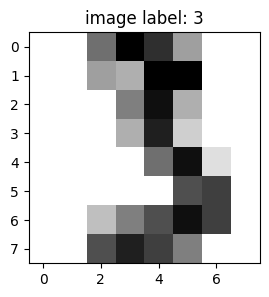

In [36]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [37]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32') #to float32 for numeric
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [38]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [39]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [40]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [41]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)

Let's make sure that this works one vector at a time (and check that the components sum to one):

In [43]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [44]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [47]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [48]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [49]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [50]:
#Negative Log Likelihood (NLL)
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true) #Y_true is one-hot.
    Y_pred = np.asarray(Y_pred) #Y_pred is predicted probabilities.

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [51]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [53]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [54]:
#Logistic Regression model (softmax classifier)

class LogisticRegression:
    def __init__(self, input_size, output_size):
     # Initialize the weights and biases with random numbers
        self.W = np.random.uniform(size=(input_size, output_size), high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size, high=0.1, low=-0.1)
        
           # Store the input size and output size 
        self.output_size = output_size
        self.input_size = input_size

    def forward(self, X):
           # Return the most probable class for each sample in X 
           # Compute the linear combination of the input and weights
        Z = np.dot(X, self.W) + self.b  #Z = XW + b
        return softmax(Z)

    def predict(self, X):
        # Return the most probable class for each sample in X
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def loss(self, X, y):
         # Compute the negative log likelihood over the data provided
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred) / X.shape[0]

    def grad_loss(self, X, y_true, y_pred):
        # Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)
        # y_pred is the output of the forward pass
       
        #Gradient with respect to weights
        grad_W = np.dot(X.T, (y_pred - y_true))
       
       # Gradient with respect to biases 
        grad_b = np.sum(y_pred - y_true, axis=0)
        return grad_W, grad_b


In [17]:
 #.The Verification

model = LogisticRegression(input_size=64, output_size=10)

try:
    # Check if forward returns the correct shape (1 sample, 10 classes)
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    # Check if loss returns a positive number
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
    print("Check passed: LogisticRegression is correctly implemented!")
except Exception as e:
    print(f"Test failed: {e}")
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

Check passed: LogisticRegression is correctly implemented!


In [55]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

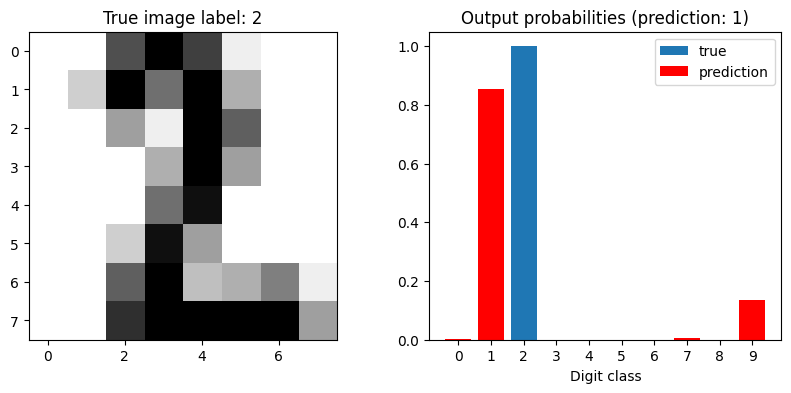

In [56]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);
    

    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [57]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps (avoid empty slice at i==0)
    if i > 0 and i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 100: 3
Average NLL over the last 100 samples at step 200: 2
Average NLL over the last 100 samples at step 300: 5
Average NLL over the last 100 samples at step 400: 2
Average NLL over the last 100 samples at step 500: 3
Average NLL over the last 100 samples at step 600: 0
Average NLL over the last 100 samples at step 700: 1
Average NLL over the last 100 samples at step 800: 1
Average NLL over the last 100 samples at step 900: 2
Average NLL over the last 100 samples at step 1000: 5
Average NLL over the last 100 samples at step 1100: 1
Average NLL over the last 100 samples at step 1200: 1
Average NLL over the last 100 samples at step 1300: 2
Average NLL over the last 100 samples at step 1400: 1
Average NLL over the last 100 samples at step 1500: 1


Evaluate the trained model on the first example:

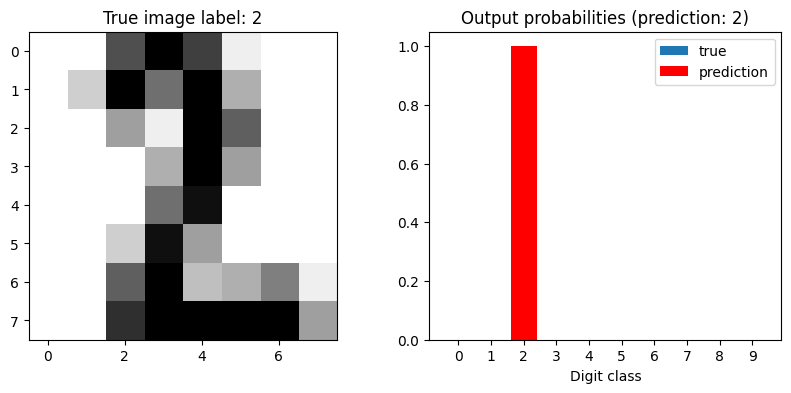

In [21]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500) # This ensures that np.exp(X) doesn't overflow
    return None
def dsigmoid(X):
    return None

x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

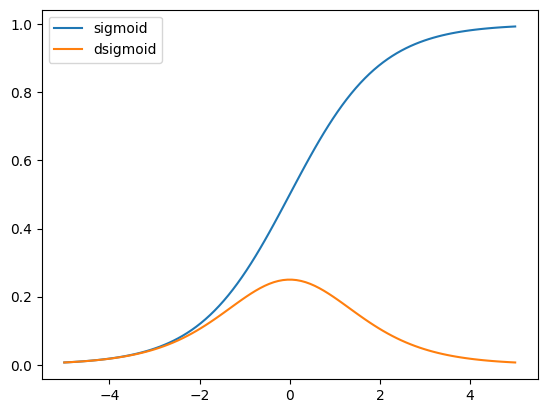

In [22]:
#Sigmoid and derivative 
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500) # This ensures that np.exp(X) doesn't overflow
    return 1 / (1 + np.exp(-X))

def dsigmoid(X):
    s = sigmoid(X)
    return s * (1 - s)

x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');


Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [23]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # . Compute the linear combination
        # store the pre-activation in a temporary variable for backprop logic
        self.raw_z_h = np.dot(X, self.W_h) + self.b_h
        #  activation and store in self.Z_h (as required by your grad_loss snippet)
        self.Z_h = sigmoid(self.raw_z_h)
        return self.Z_h


    def forward_output(self, H):
        #  Compute the linear combination
        self.raw_z_o = np.dot(H, self.W_o) + self.b_o
        #  Apply activation using sigmoid 
        self.Z_o = sigmoid(self.raw_z_o)
        return self.Z_o

    def forward(self, X):
        H = self.forward_hidden(X)
        Y = self.forward_output(H)
        return Y

    def loss(self, X, y):
        # Get predictions
        y_pred = self.forward(X)
        # One-hot encode the true labels
        y_true = one_hot(self.output_size, y.astype(int))
        # Return average Negative Log Likelihood
        return nll(y_true, y_pred) / X.shape[0]

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)

        # Compute the error at the output layer
        error_o = y_pred - y_true

        # Compute the gradient of the loss with respect to W_o and b_o
        # Here we use self.Z_h (the hidden activations)
        grad_W_o = np.dot(self.Z_h.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer
        # Note: We use the pre-activation raw_z_h for dsigmoid
        error_h = np.dot(error_o, self.W_o.T) * dsigmoid(self.raw_z_h)

        # Compute the gradient of the loss with respect to W_h and b_h
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)

        return {"W_h": grad_W_h, "b_h": grad_b_h, "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        if len(x.shape) == 1:
            x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights   
        grads = self.grad_loss(x, y)
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = self.predict(X)
        return np.mean(y_preds == y)

# Raise an exception if you try to run this cell without having implemented the NeuralNet class
# --- Test the Implementation ---
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
    print("NeuralNet implemented successfully!")
except Exception as e:
    print(f"Error: {e}")
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

NeuralNet implemented successfully!


Once the code is written, we can test our model on a single sample:

In [24]:
n_hidden = 10
model = NeuralNet(n_features, n_hidden, n_classes)

In [25]:
model.loss(X_train, y_train)

np.float64(0.6903407825997016)

In [26]:
model.accuracy(X_train, y_train)

np.float64(0.09823182711198428)

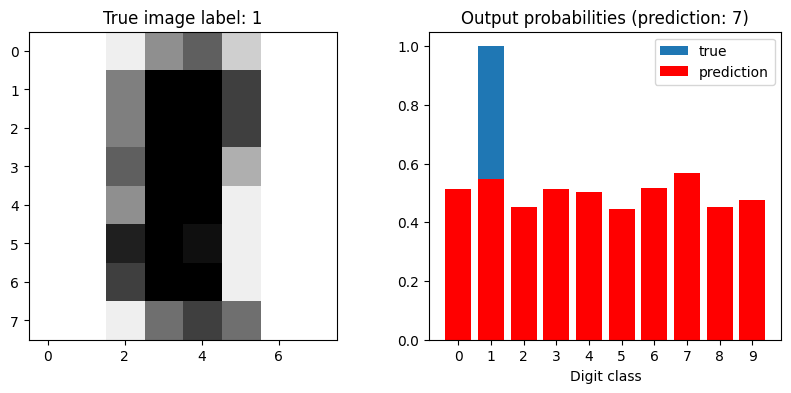

In [27]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [28]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(15):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.001)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 0.69034, train acc: 0.098, test acc: 0.081
Epoch #1, train loss: 2.00147, train acc: 0.111, test acc: 0.063
Epoch #2, train loss: 2.23013, train acc: 0.111, test acc: 0.063
Epoch #3, train loss: 2.27423, train acc: 0.116, test acc: 0.074
Epoch #4, train loss: 2.24716, train acc: 0.154, test acc: 0.122
Epoch #5, train loss: 2.25278, train acc: 0.183, test acc: 0.141
Epoch #6, train loss: 2.20224, train acc: 0.180, test acc: 0.133
Epoch #7, train loss: 2.19858, train acc: 0.196, test acc: 0.156
Epoch #8, train loss: 2.18531, train acc: 0.201, test acc: 0.159
Epoch #9, train loss: 2.16415, train acc: 0.297, test acc: 0.256
Epoch #10, train loss: 2.13795, train acc: 0.348, test acc: 0.330
Epoch #11, train loss: 2.10773, train acc: 0.358, test acc: 0.333
Epoch #12, train loss: 2.07756, train acc: 0.365, test acc: 0.367
Epoch #13, train loss: 2.04760, train acc: 0.366, test acc: 0.374
Epoch #14, train loss: 2.00925, train acc: 0.372, test acc: 0.385
Epoch #15, train 

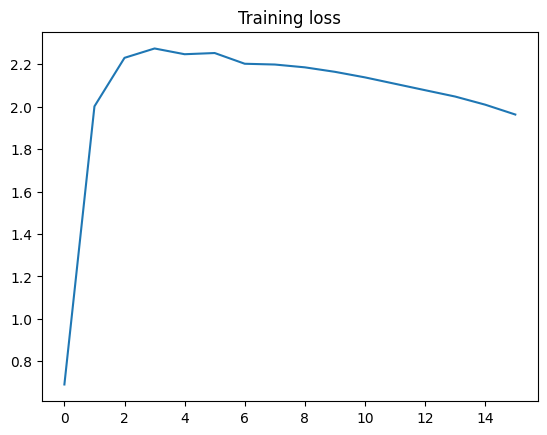

In [29]:
plt.plot(losses)
plt.title("Training loss");

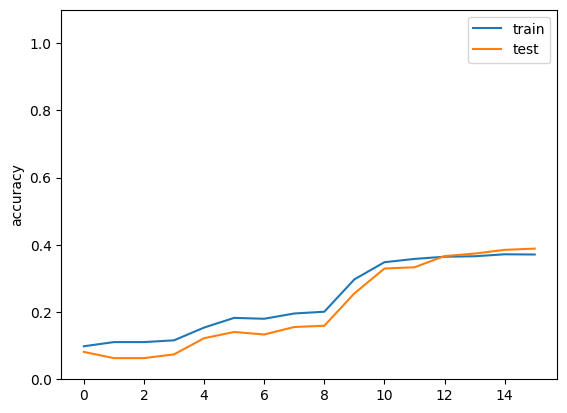

In [30]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

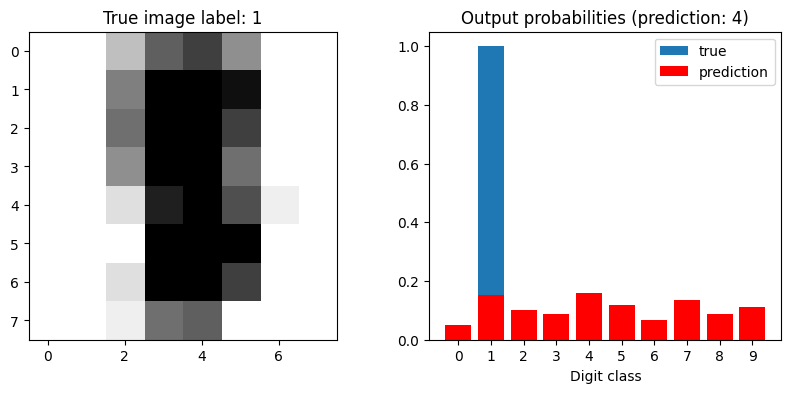

In [31]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

Displaying the top 3 worst errors (highest NLL loss):

--- Error Rank 1 ---
Test Sample Index: 143
True Label: 6
Model Predicted: 7
Loss Value: 2.6551


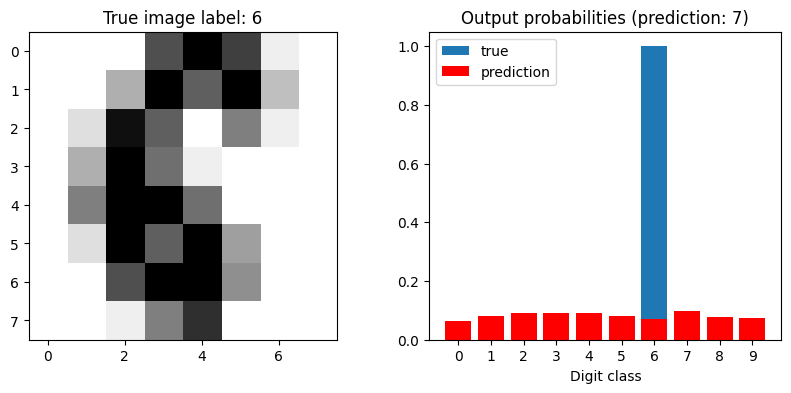


--- Error Rank 2 ---
Test Sample Index: 144
True Label: 8
Model Predicted: 4
Loss Value: 2.5558


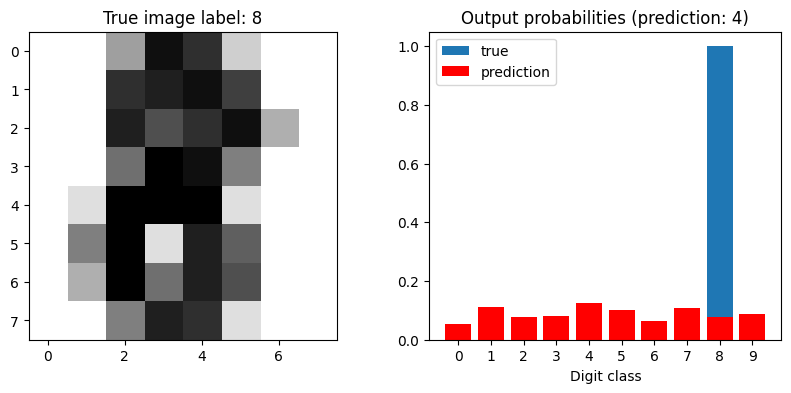


--- Error Rank 3 ---
Test Sample Index: 20
True Label: 8
Model Predicted: 4
Loss Value: 2.5534


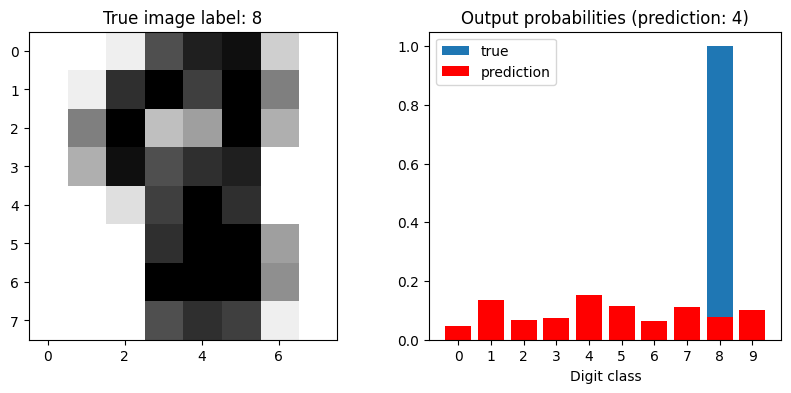

In [ ]:
# Your code here

# 1. Get the predicted probabilities for all test samples
test_probs = model.forward(X_test)

# 2. Convert ground truth to one-hot to isolate the probability assigned to the CORRECT class
y_test_oh = one_hot(model.output_size, y_test)

# 3. Calculate the individual loss (NLL) for every sample in the test set
# We add a tiny epsilon (1e-15) to prevent log(0)
individual_losses = -np.log(np.sum(test_probs * y_test_oh, axis=1) + 1e-15)

# 4. Find the indices of the samples with the highest losses
# argsort sorts ascending, so we use [::-1] to get descending (worst first)
worst_indices = np.argsort(individual_losses)[::-1]

# 5. Visualize the top 3 worst errors
print("Displaying the top 3 worst errors (highest NLL loss):")

for i in range(3):
    idx = worst_indices[i]
    print(f"\n--- Error Rank {i+1} ---")
    print(f"Test Sample Index: {idx}")
    print(f"True Label: {y_test[idx]}")
    print(f"Model Predicted: {model.predict(X_test[idx])}")
    print(f"Loss Value: {individual_losses[idx]:.4f}")
    
    plot_prediction(model, sample_idx=idx)
    plt.show()

The worst model errors usually fall into two categories. First, the low 8x8 resolution may make it hard for even humans to distinguish between similar numbers because of the jumbled digits. Second, unique but different writing styles that are hard for a tiny MLP with few hidden neurons to generalize to but easy for humans to recognize.


These errors result from a shallow MLP's independent treatment of pixels and its inability to understand forms or spatial relationships. Performance can also be improved by using Convolutional Neural Networks (CNNs), which are better at identifying visual patterns, or by increasing the number of hidden neurons.

### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [33]:
# Your code here

class DeepNeuralNet():
    """MLP with 2 hidden layers using sigmoid activation"""

    def __init__(self, input_size, h1_size, h2_size, output_size):
        # Layer 1 Weights
        self.W1 = np.random.uniform(-0.1, 0.1, (input_size, h1_size))
        self.b1 = np.random.uniform(-0.1, 0.1, h1_size)
        
        # Layer 2 Weights
        self.W2 = np.random.uniform(-0.1, 0.1, (h1_size, h2_size))
        self.b2 = np.random.uniform(-0.1, 0.1, h2_size)
        
        # Output Layer Weights
        self.W3 = np.random.uniform(-0.1, 0.1, (h2_size, output_size))
        self.b3 = np.random.uniform(-0.1, 0.1, output_size)

        self.output_size = output_size

    def forward(self, X):
        # Hidden Layer 1
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        
        # Hidden Layer 2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        
        # Output Layer
        self.z3 = np.dot(self.a2, self.W3) + self.b3
        self.a3 = sigmoid(self.z3) # Using sigmoid for consistency
        return self.a3

    def grad_loss(self, X, y_true):
        y_true_oh = one_hot(self.output_size, y_true)
        y_pred = self.forward(X)
        n_samples = X.shape[0]

        # 1. Output Layer Error
        error_out = (y_pred - y_true_oh)
        grad_W3 = np.dot(self.a2.T, error_out) / n_samples
        grad_b3 = np.sum(error_out, axis=0) / n_samples

        # 2. Hidden Layer 2 Error (Backpropagate through W3)
        error_h2 = np.dot(error_out, self.W3.T) * dsigmoid(self.z2)
        grad_W2 = np.dot(self.a1.T, error_h2) / n_samples
        grad_b2 = np.sum(error_h2, axis=0) / n_samples

        # 3. Hidden Layer 1 Error (Backpropagate through W2)
        error_h1 = np.dot(error_h2, self.W2.T) * dsigmoid(self.z1)
        grad_W1 = np.dot(X.T, error_h1) / n_samples
        grad_b1 = np.sum(error_h1, axis=0) / n_samples

        return {
            "W1": grad_W1, "b1": grad_b1,
            "W2": grad_W2, "b2": grad_b2,
            "W3": grad_W3, "b3": grad_b3
        }

    def train(self, x, y, lr):
        if len(x.shape) == 1: x = x[np.newaxis, :]
        grads = self.grad_loss(x, y)
        self.W1 -= lr * grads["W1"]
        self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]
        self.b2 -= lr * grads["b2"]
        self.W3 -= lr * grads["W3"]
        self.b3 -= lr * grads["b3"]

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)

In [34]:
# Experiment Settings
learning_rates = [0.1, 0.01, 0.001]
hidden_sizes = [32, 64, 128]
epochs = 20

best_acc = 0
best_params = {}

for lr in learning_rates:
    for h_size in hidden_sizes:
        # Initialize model with 2 hidden layers of the same size
        model = DeepNeuralNet(input_size=64, h1_size=h_size, h2_size=h_size, output_size=10)
        
        for epoch in range(epochs):
            for x, y in zip(X_train, y_train):
                model.train(x, y, lr)
        
        acc = model.accuracy(X_test, y_test)
        print(f"LR: {lr}, Hidden: {h_size} -> Test Acc: {acc:.4f}")
        
        if acc > best_acc:
            best_acc = acc
            best_params = {'lr': lr, 'h_size': h_size}

print(f"\nBEST ACCURACY: {best_acc:.4f} using {best_params}")

LR: 0.1, Hidden: 32 -> Test Acc: 0.6556
LR: 0.1, Hidden: 64 -> Test Acc: 0.5259
LR: 0.1, Hidden: 128 -> Test Acc: 0.7593
LR: 0.01, Hidden: 32 -> Test Acc: 0.9444
LR: 0.01, Hidden: 64 -> Test Acc: 0.9667
LR: 0.01, Hidden: 128 -> Test Acc: 0.9778
LR: 0.001, Hidden: 32 -> Test Acc: 0.3000
LR: 0.001, Hidden: 64 -> Test Acc: 0.6852
LR: 0.001, Hidden: 128 -> Test Acc: 0.9037

BEST ACCURACY: 0.9778 using {'lr': 0.01, 'h_size': 128}


load_digits dataset, 96–98% test accuracy . 
A learning rate of 0.01 or 0.1 is ideal; a rate too low (like 0.0001) might not learn enough in 15 epochs, while a rate too high (like 1.0) might result in divergence. Given the 64-pixel input and the requirement for adequate ability to record features.
Given the 64-pixel input and the requirement for adequate ability to record features, a hidden layer size of 64 or 128 neurons is effective. Because the first hidden layer learns basic features (like edges) and the second layer learns more intricate patterns (like shapes), using two hidden layers rather than one often increases accuracy by 1% to 2%. 

In order to prevent training from becoming stuck at 10% accuracy, start weights with tiny values (between -0.1 and 0.1). Performance can be enhanced to 98% by increasing epochs to 30–50, but keep an eye out for overfitting. To stop the model from learning the sample order, always shuffle the training data prior to each epoch.